<a href="https://colab.research.google.com/github/AndrewIsk/BrainTumourClassificationAndLLMExplination/blob/main/BrainTumourClassificationAndLLMExplination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
from PIL import Image
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.io import decode_image
from torchvision.transforms import v2
import torchvision.models as models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Import Dataset from Drive

In [12]:
listOfImagesTrain = []
listOfLabelsTrain = []
listOfImagesTest = []
listOfLabelsTest = []

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Train/notumor/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTrain.append(path)
  listOfLabelsTrain.append(0)
  #break

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Train/meningioma/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTrain.append(path)
  listOfLabelsTrain.append(1)

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Train/glioma/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTrain.append(path)
  listOfLabelsTrain.append(2)

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Train/pituitary/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTrain.append(path)
  listOfLabelsTrain.append(3)


paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Test/notumor/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTest.append(path)
  listOfLabelsTest.append(0)

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Test/meningioma/"


for path in os.listdir(paths):
  path = paths+path
  listOfImagesTest.append(path)
  listOfLabelsTest.append(1)

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Test/glioma/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTest.append(path)
  listOfLabelsTest.append(2)

paths = "/content/drive/MyDrive/Epic and CSCR hospital Dataset/Test/pituitary/"

for path in os.listdir(paths):
  path = paths+path
  listOfImagesTest.append(path)
  listOfLabelsTest.append(3)


classes = ['No Tumor', 'Meningioma', 'Glioma', 'Pituitary']

Custom Dataset  / DataLoader

In [4]:
transform = v2.Compose([
    v2.Resize((128, 128)),
    v2.ToTensor()
])

class MRIImages(Dataset):
    def __init__(self, listOfImages, listOfLabels, train=True, transform=transform):
        self.listOfImages = listOfImages
        self.listOfLabels = listOfLabels
        self.transform = transform

    def __len__(self):
        return len(self.listOfImages)

    def __getitem__(self, idx):
        image = Image.open(self.listOfImages[idx]).convert("RGB")
        label = self.listOfLabels[idx]
        if self.transform:
          image = self.transform(image)
        return image, label


datasetImagesAndLabels = MRIImages(listOfImagesTrain, listOfLabelsTrain)

splitRatio = [int(len(datasetImagesAndLabels)*0.8), int(len(datasetImagesAndLabels)*0.2)]
trainImagesAndLabels, validationImagesAndLabels = random_split(datasetImagesAndLabels, splitRatio)

trainLoader = DataLoader(trainImagesAndLabels, batch_size=64, shuffle=True, drop_last=True)
validationLoader = DataLoader(validationImagesAndLabels, batch_size=64, shuffle=True, drop_last=True)

datasetImagesAndLabels = MRIImages(listOfImagesTest, listOfLabelsTest)
testLoader = DataLoader(datasetImagesAndLabels, batch_size=len(datasetImagesAndLabels), shuffle=True, drop_last=True)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [5]:
for images, labels in trainLoader:
  #print(images.shape)
  #print(labels.shape)
  break

In [6]:
model = models.resnet18(pretrained=True)

numFeatures = model.fc.in_features
model.fc = torch.nn.Linear(numFeatures, 4)

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
trainLoss = []
validationLoss = []
numEpochs = 10
runningLoss = 0
runningValLoss = 0
accuracyTrain = 0
accuracyValidation = 0
totalTrain = 0
totalValidation = 0

for epoch in range(numEpochs):
  print(f'Epoch: {epoch+1}')
  model.train()
  for i, data in enumerate(trainLoader):
    trainImage, trainLabel = data
    optimizer.zero_grad()

    outputs = model(trainImage)
    loss = criterion(outputs, trainLabel)
    loss.backward()

    optimizer.step()

    runningLoss += loss.item()
    trainLoss.append(loss.item())
    if len(trainLoss) % 63 == 0:
      print(f'Train Loss: {trainLoss[-64:]}')

    #print(f"Train Labels: {trainLabel[:20]}")
    _, predicted = torch.max(outputs,1)
    #print(f"Train Predicted: {predicted[:20]}")
    accuracyTrain += accuracy_score(trainLabel, predicted, normalize=False)
    totalTrain += len(trainLabel)

  model.eval()
  for i, data in enumerate(validationLoader):
    validationImage, validationLabel = data
    with torch.no_grad():

      outputs = model(validationImage)
      loss = criterion(outputs, validationLabel)

      runningLoss += loss.item()
      validationLoss.append(loss.item())
      if len(validationLoss) % 64 == 0:
        print(f'Validation Loss: {validationLoss[-64:]}')

      #print(f"Validation Labels: {validationLabel[:20]}")
      _, predicted = torch.max(outputs,1)
      #print(f"Validation Predicted: {predicted[:20]}")
      accuracyValidation += accuracy_score(validationLabel, predicted, normalize=False)
      totalValidation += len(validationLabel)

  print(f'Train Accuracy: {accuracyTrain/totalTrain}')
  print(f'Validation Accuracy: {accuracyValidation/totalValidation}')
  torch.save(model.state_dict(), "bestModel.pth")

Epoch: 1
Train Loss: [1.5857555866241455, 1.264456868171692, 1.0080654621124268, 0.8913220763206482, 0.8604226112365723, 0.7375872731208801, 0.7709249258041382, 0.7130290269851685, 0.5447289347648621, 0.6902268528938293, 0.40108156204223633, 0.37390491366386414, 0.47084376215934753, 0.32082244753837585, 0.6501197218894958, 0.42335623502731323, 0.45421528816223145, 0.5354114770889282, 0.590718686580658, 0.35127875208854675, 0.3062577247619629, 0.3472971022129059, 0.405224472284317, 0.4521399736404419, 0.4678933322429657, 0.35488080978393555, 0.28538423776626587, 0.4848810136318207, 0.4167693257331848, 0.2653723955154419, 0.29503732919692993, 0.29048603773117065, 0.23482148349285126, 0.21554826200008392, 0.187114417552948, 0.22623227536678314, 0.2622205913066864, 0.22587893903255463, 0.3650013208389282, 0.35550516843795776, 0.370486319065094, 0.5244839787483215, 0.28446635603904724, 0.13771818578243256, 0.225480318069458, 0.32470762729644775, 0.1787269115447998, 0.1291346400976181, 0.285

In [8]:
testCorrect = 0
testTotal = 0
for i, data in enumerate(testLoader):
  testImage, testLabel = data

  with torch.no_grad():
    outputs = model(testImage)

    #print(f"Test Labels: {testLabel}")
    _, predicted = torch.max(outputs,1)
    #print(f"Test Predicted: {predicted}")
    testCorrect += accuracy_score(testLabel, predicted, normalize=False)
    testTotal += len(testLabel)

  print(f'Test Accuracy: {testCorrect/testTotal}')

Test Accuracy: 0.9494614747307374


In [13]:
print(classification_report(testLabel, predicted,target_names = classes))

              precision    recall  f1-score   support

    No Tumor       0.96      1.00      0.98       487
  Meningioma       0.92      0.91      0.92       546
      Glioma       0.95      0.90      0.92       755
   Pituitary       0.97      1.00      0.98       626

    accuracy                           0.95      2414
   macro avg       0.95      0.95      0.95      2414
weighted avg       0.95      0.95      0.95      2414



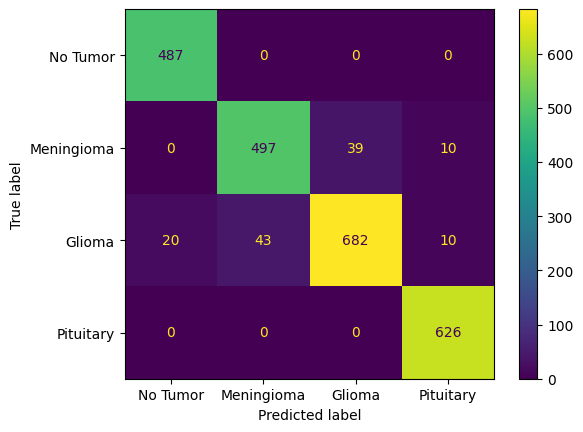

In [16]:
cm = confusion_matrix(testLabel, predicted)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot()
plt.show()